<a href="https://colab.research.google.com/github/KokkiralaSowndarya/final_project/blob/main/Zomato_and_Swiggy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Step 1: Import libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
zomato = pd.read_csv("/content/zomato.csv")
swiggy = pd.read_csv("/content/swiggy.csv")

print(zomato.head())
print(swiggy.head())


      App      review_date                                 review_description  \
0  Zomato  7/23/2023 15:52  So basically , it's the best approach you'll e...   
1  Zomato    7/8/2023 4:32  Always Late Delivery. No change. Late delivery...   
2  Zomato  7/24/2023 21:14  This app is froude with their zomato gold, i h...   
3  Zomato  7/24/2023 17:07  I tried 100 times adding an alternate number i...   
4  Zomato  7/22/2023 13:28  In recent years, Zomato support has become les...   

   rating  thumbsUpCount                                 developer_response  \
0       5             99                                                NaN   
1       1            416  Hi Magesh, sorry to hear about that. Please wr...   
2       1              1  Hi there, we are really sorry for the bad expe...   
3       1              1  Hi there, we are really sorry for the bad expe...   
4       1             30  Hi Shaik, we're sorry to hear that. We are con...   

  developer_response_date appVersion  

In [ ]:

print(zomato.columns)
print(swiggy.columns)

Index(['App', 'review_date', 'review_description', 'rating', 'thumbsUpCount',
       'developer_response', 'developer_response_date', 'appVersion'],
      dtype='object')
Index(['App', 'review_date', 'review_description', 'rating', 'thumbsUpCount',
       'developer_response', 'developer_response_date', 'appVersion'],
      dtype='object')


In [ ]:
zomato = zomato[['review_description', 'rating']]
swiggy = swiggy[['review_description', 'rating']]

In [ ]:
zomato = zomato.rename(columns={'review_description': 'review'})
swiggy = swiggy.rename(columns={'review_description': 'review'})

zomato['source'] = 'zomato'
swiggy['source'] = 'swiggy'

In [ ]:
data = pd.concat([zomato, swiggy], ignore_index=True)

print(data.head())
print(data.shape)
print(data.tail())

                                              review  rating  source
0  So basically , it's the best approach you'll e...       5  zomato
1  Always Late Delivery. No change. Late delivery...       1  zomato
2  This app is froude with their zomato gold, i h...       1  zomato
3  I tried 100 times adding an alternate number i...       1  zomato
4  In recent years, Zomato support has become les...       1  zomato
(465660, 3)
                                  review  rating  source
465655  Very Good Experience with Swiffy       5  swiggy
465656            Good offers. Best food       5  swiggy
465657   It's real awesome fast delivery       5  swiggy
465658            Super app, and healful       5  swiggy
465659                very user friendly       5  swiggy


In [ ]:
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data.dropna(subset=['review', 'rating'], inplace=True)

In [ ]:
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

In [ ]:
data['sentiment'] = data['rating'].apply(get_sentiment)

print(data[['rating','sentiment']].head())
print(data[['rating','sentiment']].tail())

   rating sentiment
0       5  positive
1       1  negative
2       1  negative
3       1  negative
4       1  negative
        rating sentiment
465655       5  positive
465656       5  positive
465657       5  positive
465658       5  positive
465659       5  positive


In [ ]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

data['clean_review'] = data['review'].apply(clean_text)

print(data[['review','clean_review']].head())

                                              review  \
0  So basically , it's the best approach you'll e...   
1  Always Late Delivery. No change. Late delivery...   
2  This app is froude with their zomato gold, i h...   
3  I tried 100 times adding an alternate number i...   
4  In recent years, Zomato support has become les...   

                                        clean_review  
0  basic best approach ever find like everi resta...  
1  alway late deliveri chang late deliveri map sh...  
2  app froud zomato gold subscrib gold membership...  
3  tri time ad altern number applic done due netw...  
4  recent year zomato support becom less respons ...  


In [ ]:
# Reduce data
data = data.sample(50000, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(data['clean_review'])
y = data['sentiment']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fast Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.849


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

    negative       0.87      0.88      0.87      5040
     neutral       0.00      0.00      0.00       443
    positive       0.83      0.90      0.86      4517

    accuracy                           0.85     10000
   macro avg       0.57      0.59      0.58     10000
weighted avg       0.81      0.85      0.83     10000



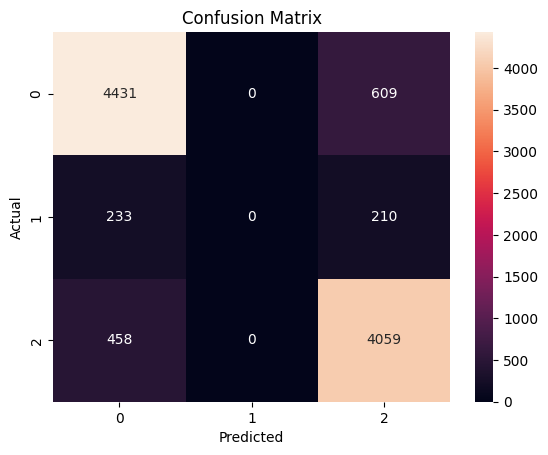

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

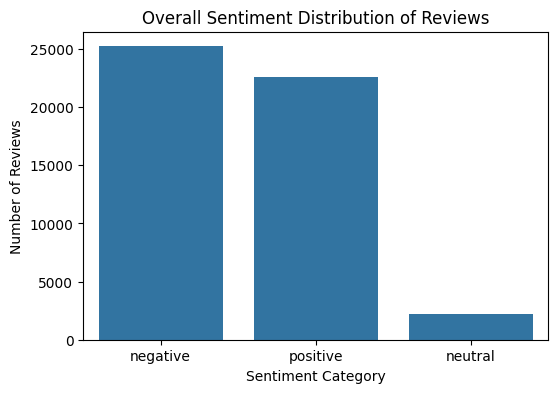

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=data, x='sentiment')
plt.title("Overall Sentiment Distribution of Reviews")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")
plt.show()

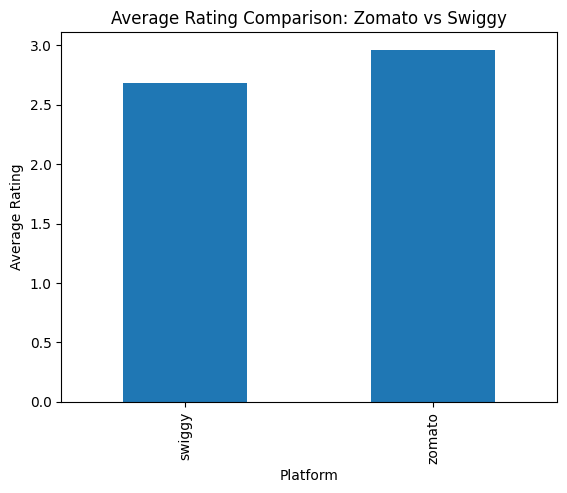

In [ ]:
avg_rating = data.groupby('source')['rating'].mean()

avg_rating.plot(kind='bar')
plt.title("Average Rating Comparison: Zomato vs Swiggy")
plt.xlabel("Platform")
plt.ylabel("Average Rating")
plt.show()

In [ ]:
sample = [" food was neutral"]

sample_clean = [clean_text(i) for i in sample]
sample_vec = tfidf.transform(sample_clean)

prediction = rf_model.predict(sample_vec)

print("Prediction:", prediction[0])

Prediction: positive
